In [1]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import colormaps as cm
import pandas as pd
import math
from graphcast.losses import normalized_latitude_weights

In [34]:
def plot_rmse(ax, prediction1, prediction2, target1, target2,
              pred1_label, pred2_label, var_name=None, 
              units=None, level=None):
    """Plot RMSE of two predictions against their targets on a given axis."""

    def compute_rmse(pred, target):
        return np.sqrt(((target - pred) ** 2).mean(dim=('time', 'lat', 'lon')))

    rmse1 = compute_rmse(prediction1, target1)
    rmse2 = compute_rmse(prediction2, target2)

    ax.plot(rmse1, linewidth=2, label=pred1_label)
    ax.plot(rmse2, linewidth=2, label=pred2_label)

    ax.set_xticks(np.arange(3, 40, 4))
    ax.set_xticklabels(np.arange(1, 11))
    ax.set_xlabel("Lead time [in days]", fontsize=12)

    ylabel = f"RMSE [in {units}]" if units else "RMSE"
    ax.set_ylabel(ylabel, fontsize=12)

    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

    if var_name:
        title = var_name
        if level is not None:
            title += f", level={level:.2f}"
        ax.set_title(title, fontsize=12, fontweight="bold")

    ax.legend(loc='best', frameon=True)
    
    plt.tight_layout()
    
    return ax

In [33]:
def plot_lw_rmse(ax, prediction1, prediction2, target1, target2,
                 pred1_label, pred2_label, var_name=None, units=None, 
                 level=None, ls=["-","-"], color=["C0","C1"], xlabel="",
                 ylabel="",):
    """Plot latitude weighted RMSE of two predictions against their targets on a given axis."""

    def compute_lw_rmse(pred, target):
        sqerr = (target - pred) ** 2
        sqerr *= normalized_latitude_weights(target).astype(sqerr.dtype)
        return np.sqrt((sqerr.mean(dim=("time", "lat", "lon"))))

    rmse1 = compute_lw_rmse(prediction1, target1)
    rmse2 = compute_lw_rmse(prediction2, target2)

    ax.plot(rmse1, linewidth=2, label=pred1_label, linestyle=ls[0], color=color[0])
    ax.plot(rmse2, linewidth=2, label=pred2_label, linestyle=ls[1], color=color[1])

    ax.set_xticks(np.arange(3, 40, 4))
    ax.set_xticklabels(np.arange(1, 11))
    if len(xlabel)==0:
        xlabel = "Lead time [in days]"
    ax.set_xlabel(xlabel, fontsize=12)

    if len(ylabel)==0:
        ylabel = f"LW-RMSE [in {units}]" if units else "LW-RMSE"
    else:
        ylabel = f"{ylabel} [in {units}]" if units else ylabel
    ax.set_ylabel(ylabel, fontsize=12)

    ax.tick_params(axis="both", labelsize=12)
    ax.grid(True, which="both", linestyle=':', linewidth=0.5)

    if var_name:
        title = var_name
        if level is not None:
            title += f", level={level:.2f}"
        ax.set_title(title, fontsize=12, fontweight="bold")

    ax.legend(loc="best", frameon=True)
    
    plt.tight_layout()
    
    return ax

In [32]:
def plot_mae(ax, prediction1, prediction2, target1, target2,
             pred1_label, pred2_label, var_name=None, units=None, 
             level=None):
    """Plot MAE of two predictions against target on a given axis."""

    def compute_mae(pred, target):
        abs_error = abs(target - pred)
        return abs_error.mean(dim=("time", "lat", "lon"))

    mae1 = compute_mae(prediction1, target1)
    mae2 = compute_mae(prediction2, target2)

    ax.plot(mae1, linewidth=2, label=pred1_label)
    ax.plot(mae2, linewidth=2, label=pred2_label)

    ax.set_xticks(np.arange(3, 40, 4))
    ax.set_xticklabels(np.arange(1, 11))
    ax.set_xlabel("Lead time [in days]", fontsize=12)

    ylabel = f"MAE [in {units}]" if units else "MAE"
    ax.set_ylabel(ylabel, fontsize=12)

    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

    if var_name:
        title = var_name
        if level is not None:
            title += f", level={level:.2f}"
        ax.set_title(title, fontsize=12, fontweight="bold")

    ax.legend(loc='best', frameon=True)
    
    plt.tight_layout()

    return ax

In [31]:
def plot_lw_mae(ax, prediction1, prediction2, target1, target2,
                pred1_label, pred2_label, var_name=None, units=None, 
                level=None, ls=["-","-"], color=["C0","C1"], xlabel="", 
                ylabel=""):
    """Plot grid-cell weighted MAE of two predictions against target on a given axis."""

    def compute_lw_mae(pred, target):
        abs_error = abs(target - pred)
        abs_error *= normalized_latitude_weights(target).astype(abs_error.dtype)
        return abs_error.mean(dim=("time", "lat", "lon"))

    mae1 = compute_lw_mae(prediction1, target1)
    mae2 = compute_lw_mae(prediction2, target2)

    ax.plot(mae1, linewidth=2, label=pred1_label, linestyle=ls[0], color=color[0])
    ax.plot(mae2, linewidth=2, label=pred2_label, linestyle=ls[1], color=color[1])

    ax.set_xticks(np.arange(3, 40, 4))
    ax.set_xticklabels(np.arange(1, 11))
    if len(xlabel)==0:
        xlabel = "Lead time [in days]"
    ax.set_xlabel(xlabel, fontsize=12)

    if len(ylabel)==0:
        ylabel = f"LW-MAE [in {units}]" if units else "LW-MAE"
    else:
        ylabel = f"{ylabel} [in {units}]" if units else ylabel
    ax.set_ylabel(ylabel, fontsize=12)

    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

    if var_name:
        title = var_name
        if level is not None:
            title += f", level={level:.2f}"
        ax.set_title(title, fontsize=12, fontweight="bold")

    ax.legend(loc='best', frameon=True)
    
    plt.tight_layout()
    
    return ax

In [6]:
# metadata
_scratch = "/pscratch/sd/n/nagarwal/"

_prototype1 = "atm-only"; _expt1 = "R0"
_prototype2 = "atm-wocnsfc"; _expt2 = "R0"
_prototype_home = "/global/homes/n/nagarwal/graph-ufs/prototypes/"

_inference1_dir = os.path.join(_scratch, _prototype1, _expt1, "inference", "validation")
_inference2_dir = os.path.join(_scratch, _prototype2, _expt2, "inference", "validation")

_figdir = os.path.join(os.getcwd(), "figures")

# RMSE Error

In [11]:
eval_dates = ["2022-01-01T00", "2022-12-31T18"]

In [12]:
# GraphUFS predictions
fname = "graphufs.240h.zarr"
ds_pred1 = xr.open_zarr(os.path.join(_inference1_dir, fname))
ds_pred1 = ds_pred1.sel(time=slice(eval_dates[0], eval_dates[1]))
ds_pred2 = xr.open_zarr(os.path.join(_inference2_dir, fname))
ds_pred2 = ds_pred2.sel(time=slice(eval_dates[0], eval_dates[1]))

# common target
fname = "replay.240h.zarr"
ds_tar1 = xr.open_zarr(os.path.join(_inference1_dir, fname))
ds_tar1 = ds_tar1.sel(time=slice(eval_dates[0], eval_dates[1]))
ds_tar2 = xr.open_zarr(os.path.join(_inference2_dir, fname))
ds_tar2 = ds_tar2.sel(time=slice(eval_dates[0], eval_dates[1]))

In [13]:
ds_pred1

<xarray.Dataset> Size: 586GB
Dimensions:    (time: 584, lead_time: 40, level: 16, lat: 192, lon: 384)
Coordinates:
  * lat        (lat) float64 2kB 89.82 88.89 87.95 ... -87.25 -88.18 -89.12
  * lead_time  (lead_time) timedelta64[ns] 320B 0 days 06:00:00 ... 10 days 0...
  * level      (level) float64 128B 226.1 277.8 327.7 ... 874.7 922.6 974.3
  * lon        (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * time       (time) datetime64[ns] 5kB 2022-01-01T03:00:00 ... 2022-12-31T1...
Data variables:
    dzdt       (time, lead_time, level, lat, lon) float32 110GB dask.array<chunksize=(1, 40, 16, 192, 384), meta=np.ndarray>
    pressfc    (time, lead_time, lat, lon) float32 7GB dask.array<chunksize=(1, 40, 192, 384), meta=np.ndarray>
    spfh       (time, lead_time, level, lat, lon) float32 110GB dask.array<chunksize=(1, 40, 16, 192, 384), meta=np.ndarray>
    spfh2m     (time, lead_time, lat, lon) float32 7GB dask.array<chunksize=(1, 40, 192, 384), meta=np.ndarray>
    tmp        (time, lead_time, level, lat, lon) float32 110GB dask.array<chunksize=(1, 40, 16, 192, 384), meta=np.ndarray>
    tmp2m      (time, lead_time, lat, lon) float32 7GB dask.array<chunksize=(1, 40, 192, 384), meta=np.ndarray>
    ugrd       (time, lead_time, level, lat, lon) float32 110GB dask.array<chunksize=(1, 40, 16, 192, 384), meta=np.ndarray>
    ugrd10m    (time, lead_time, lat, lon) float32 7GB dask.array<chunksize=(1, 40, 192, 384), meta=np.ndarray>
    vgrd       (time, lead_time, level, lat, lon) float32 110GB dask.array<chunksize=(1, 40, 16, 192, 384), meta=np.ndarray>
    vgrd10m    (time, lead_time, lat, lon) float32 7GB dask.array<chunksize=(1, 40, 192, 384), meta=np.ndarray>

In [14]:
coords = ["lat", "lon", "level", "time", "lead_time"]
common_vars = [v for v in ds_pred1.variables if v in ds_pred2.variables and v not in coords]
common_vars_3d = [v for v in common_vars if "level" in ds_pred2[v].coords]
common_vars_2d = list(set(common_vars) - set(common_vars_3d))

## RMSE

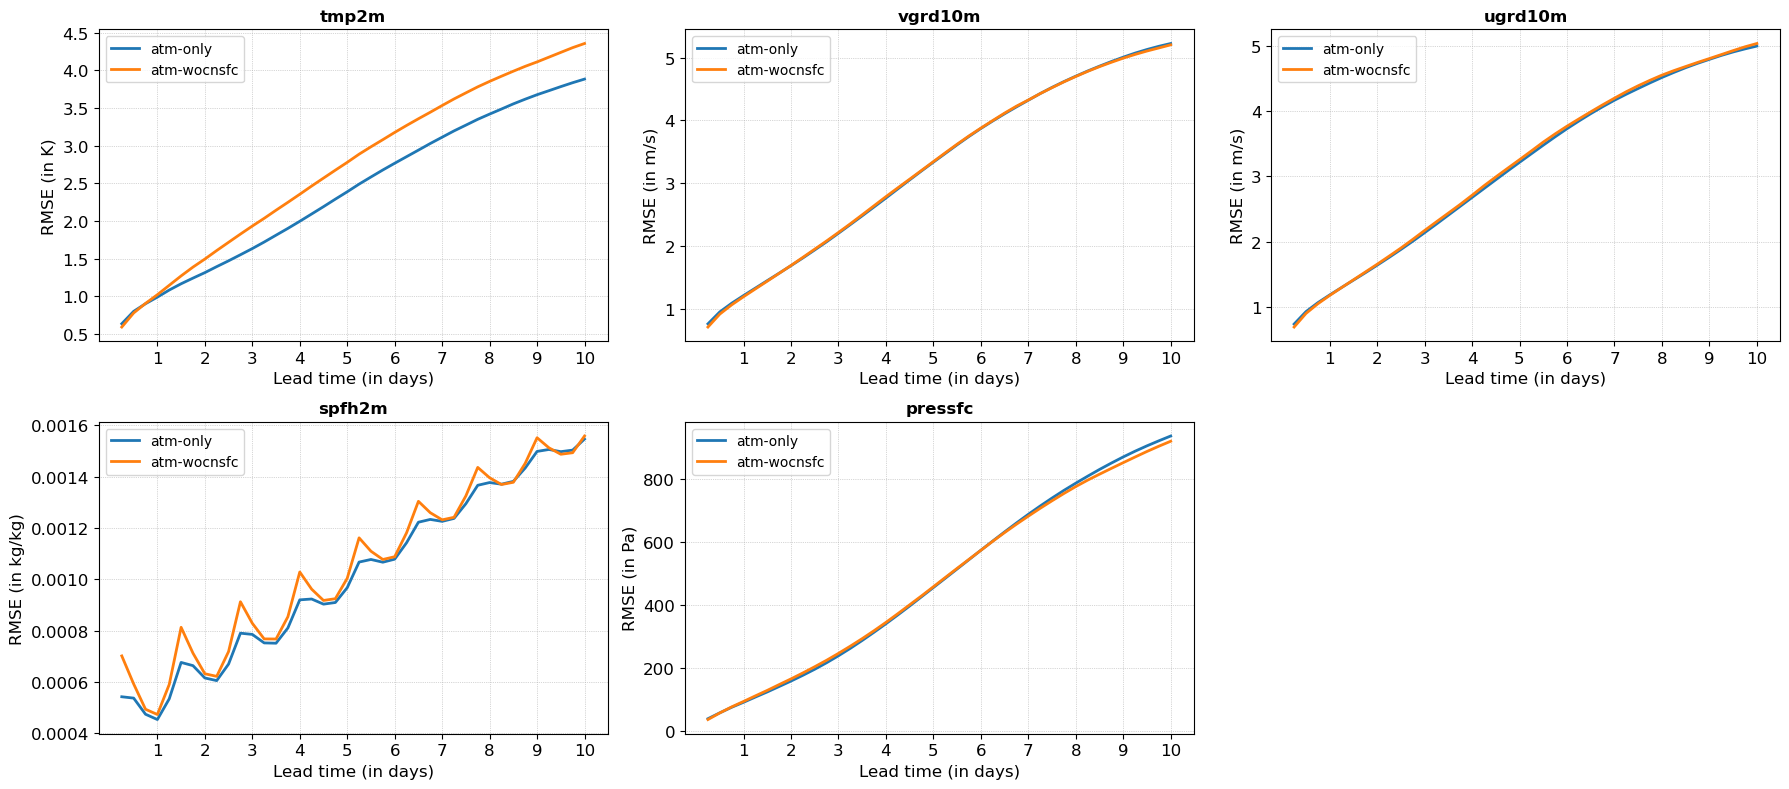

In [15]:
# plot -- 2D variables 
### NO LATITUDE WEIGHTING
nvars = len(common_vars_2d)
ncols = math.ceil(math.sqrt(nvars)) # make a square-ish box
nrows = math.ceil(nvars / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6,nrows*4))
axes = np.array(axes).flatten()

for i, v in enumerate(common_vars_2d):
    _ = plot_rmse(axes[i], ds_pred1[v], ds_pred2[v], ds_tar1[v], ds_tar2[v], _prototype1, _prototype2,
                  var_name=v, units=ds_tar1[v].units)

for j in range(nvars, len(axes)): # turn off the unused axes
    axes[j].axis("off")

plt.tight_layout()
#plt.savefig("figures/RMSEs_atm-only_vs_atm-wocnsfc_2d_atm_vars.png", dpi=300)
plt.show()

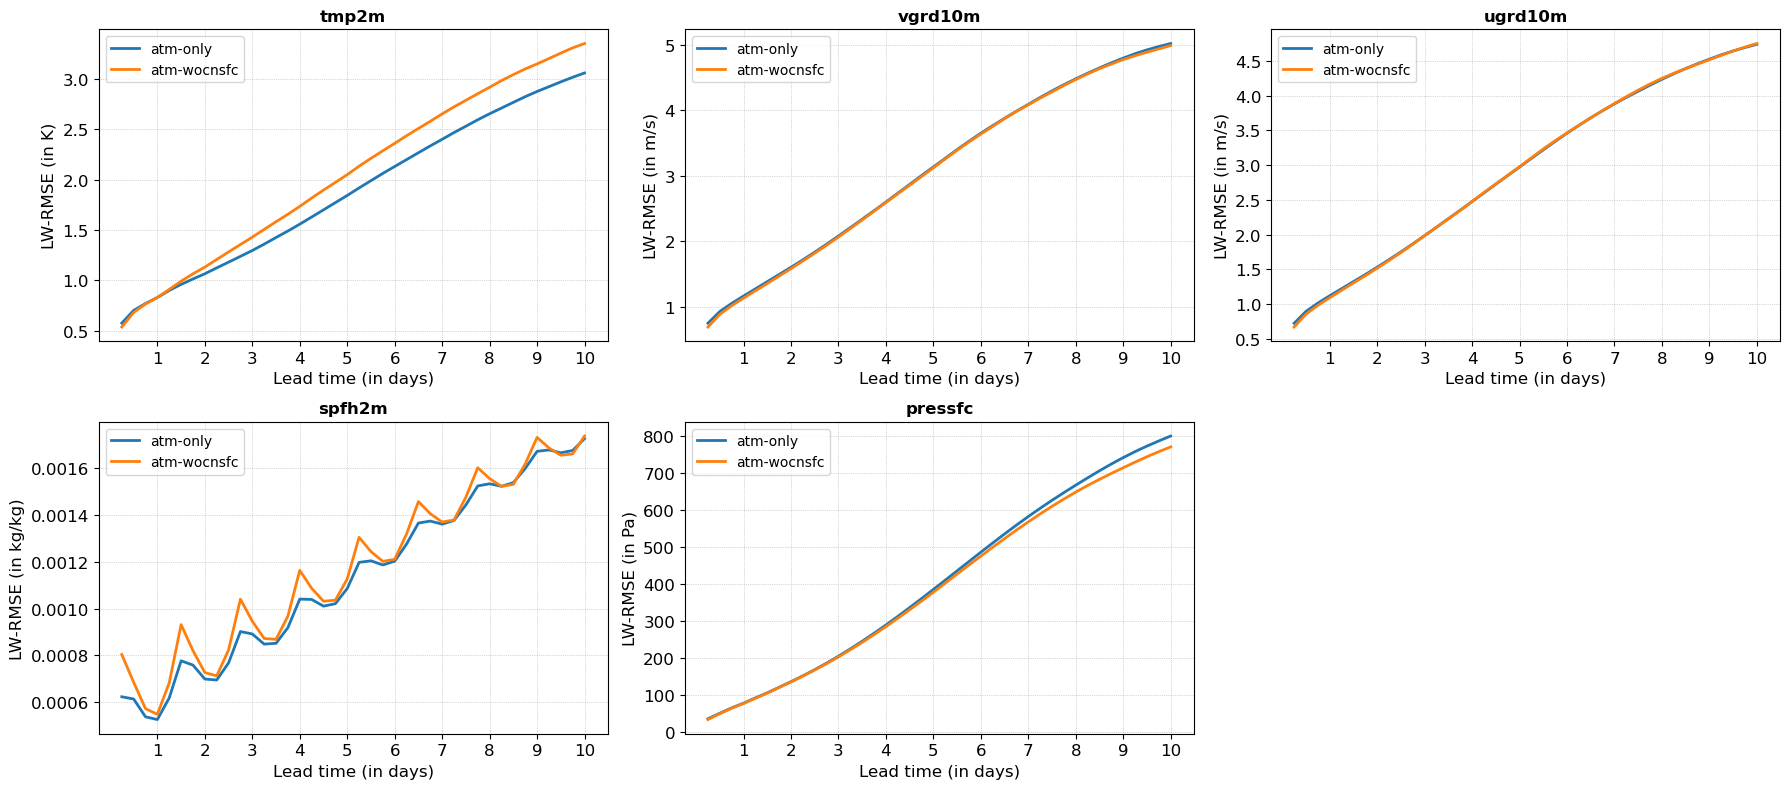

In [16]:
# plot -- 2D variables 
### LATITUDE WEIGHTED
nvars = len(common_vars_2d)
ncols = math.ceil(math.sqrt(nvars)) # make a square-ish box
nrows = math.ceil(nvars / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6,nrows*4))
axes = np.array(axes).flatten()

for i, v in enumerate(common_vars_2d):
    _ = plot_lw_rmse(axes[i], ds_pred1[v], ds_pred2[v], ds_tar1[v], ds_tar2[v], _prototype1, _prototype2,
                  var_name=v, units=ds_tar1[v].units)

for j in range(nvars, len(axes)): # turn off the unused axes
    axes[j].axis("off")

plt.tight_layout()
#plt.savefig("figures/RMSEs_atm-only_vs_atm-wocnsfc_2d_atm_vars_latitude_weighted.png", dpi=300)
plt.show()


KeyboardInterrupt



Error in callback <function _draw_all_if_interactive at 0x7f6ec34edee0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

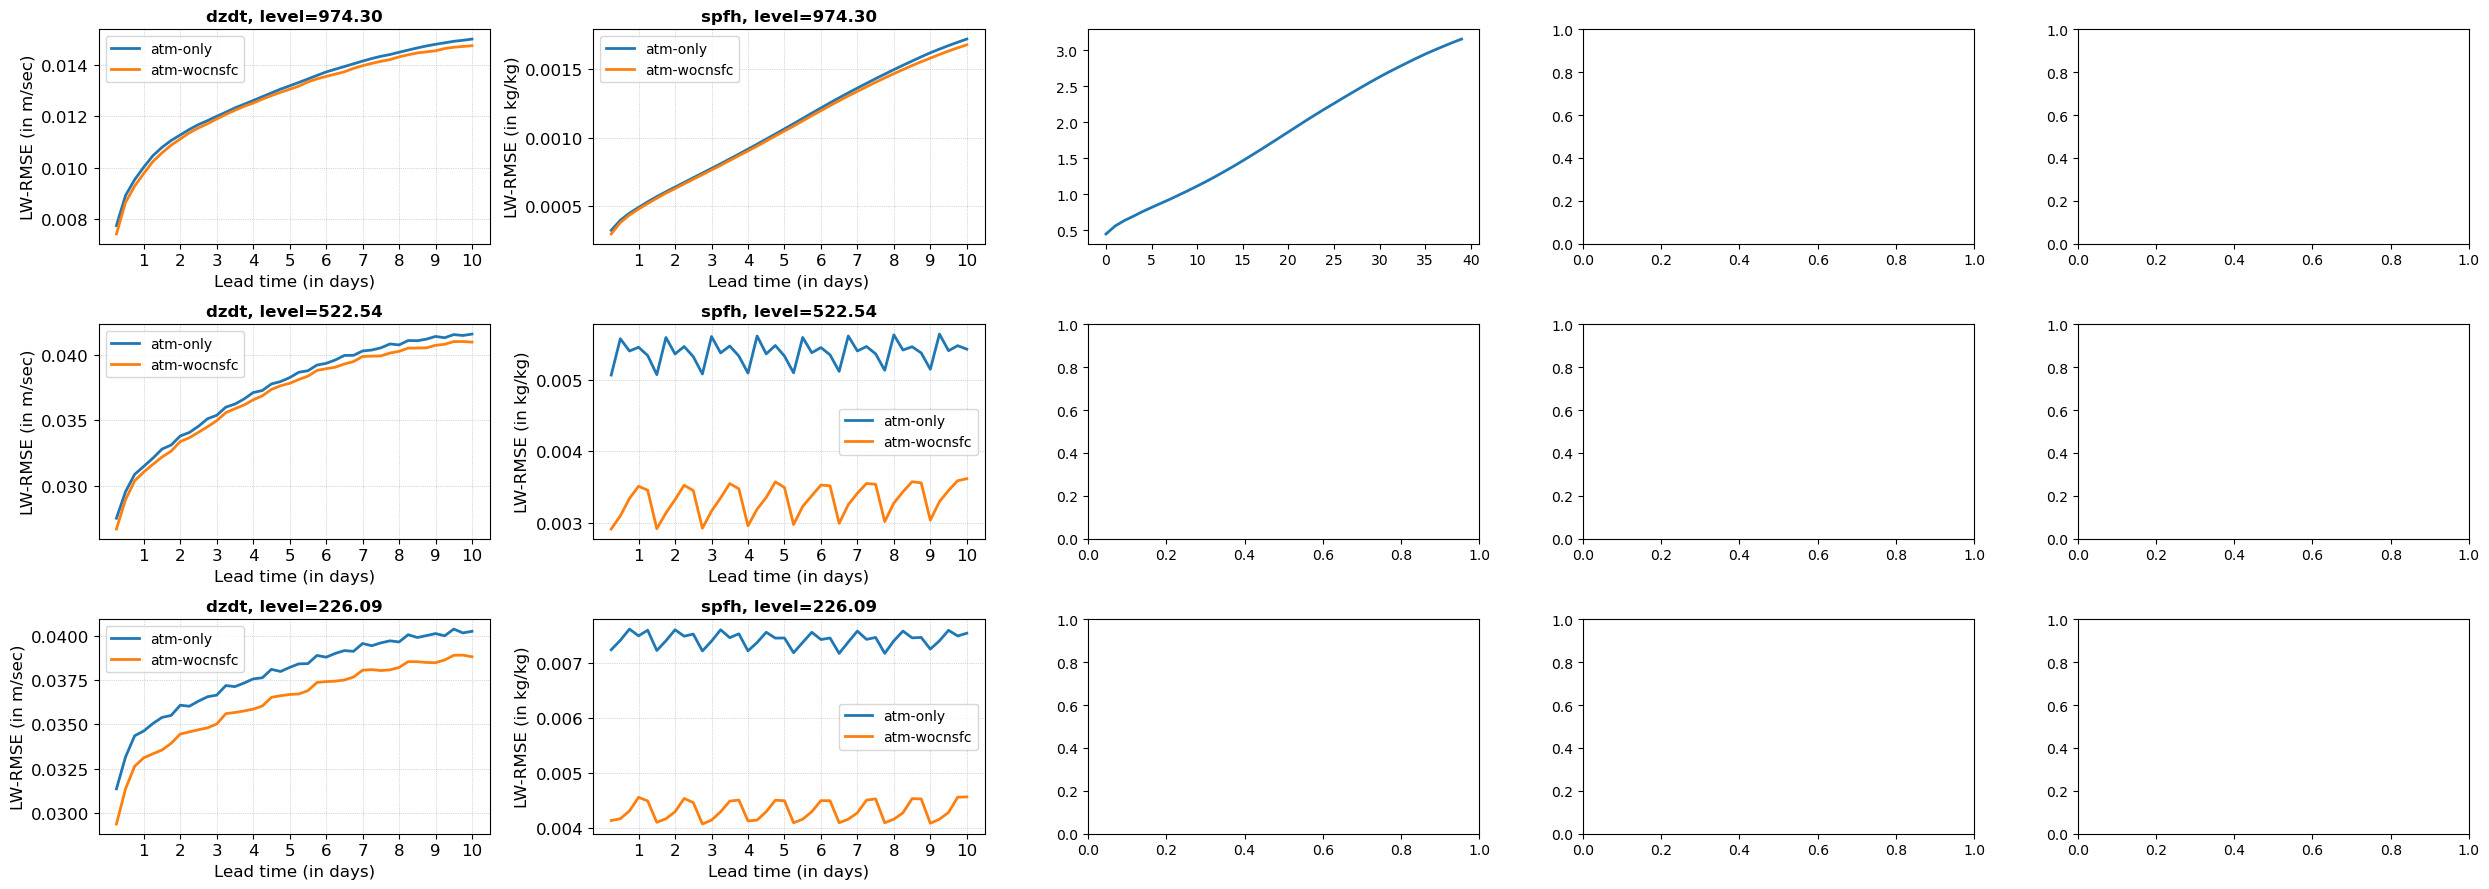

In [17]:
# plot - 3D variables
levels = [1000, 500, 200]
var = common_vars_3d
nvars = len(var)
ncols = nvars # make a square-ish box
nrows = len(levels)
#nrows = ds_pred1.sizes["level"]

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5,nrows*3))

for j, v in enumerate(var):
    for i, level in enumerate(levels): 
        _ = plot_lw_rmse(axes[i][j], ds_pred1[v].sel(level=level, method="nearest"), ds_pred2[v].sel(level=level, method="nearest"), 
                      ds_tar1[v].sel(level=level, method="nearest"), ds_tar2[v].sel(level=level, method="nearest"), _prototype1, 
                      _prototype2, var_name=v, units=ds_tar1[v].units, level=ds_pred1.coords["level"].sel(level=level, method="nearest").values)

#plt.savefig("figures/RMSEs_atm-only_vs_atm-wocnsfc_3d_atm_vars_200-500-1000hPa_latitude_weighted.png", dpi=300)
plt.show()

## MAE

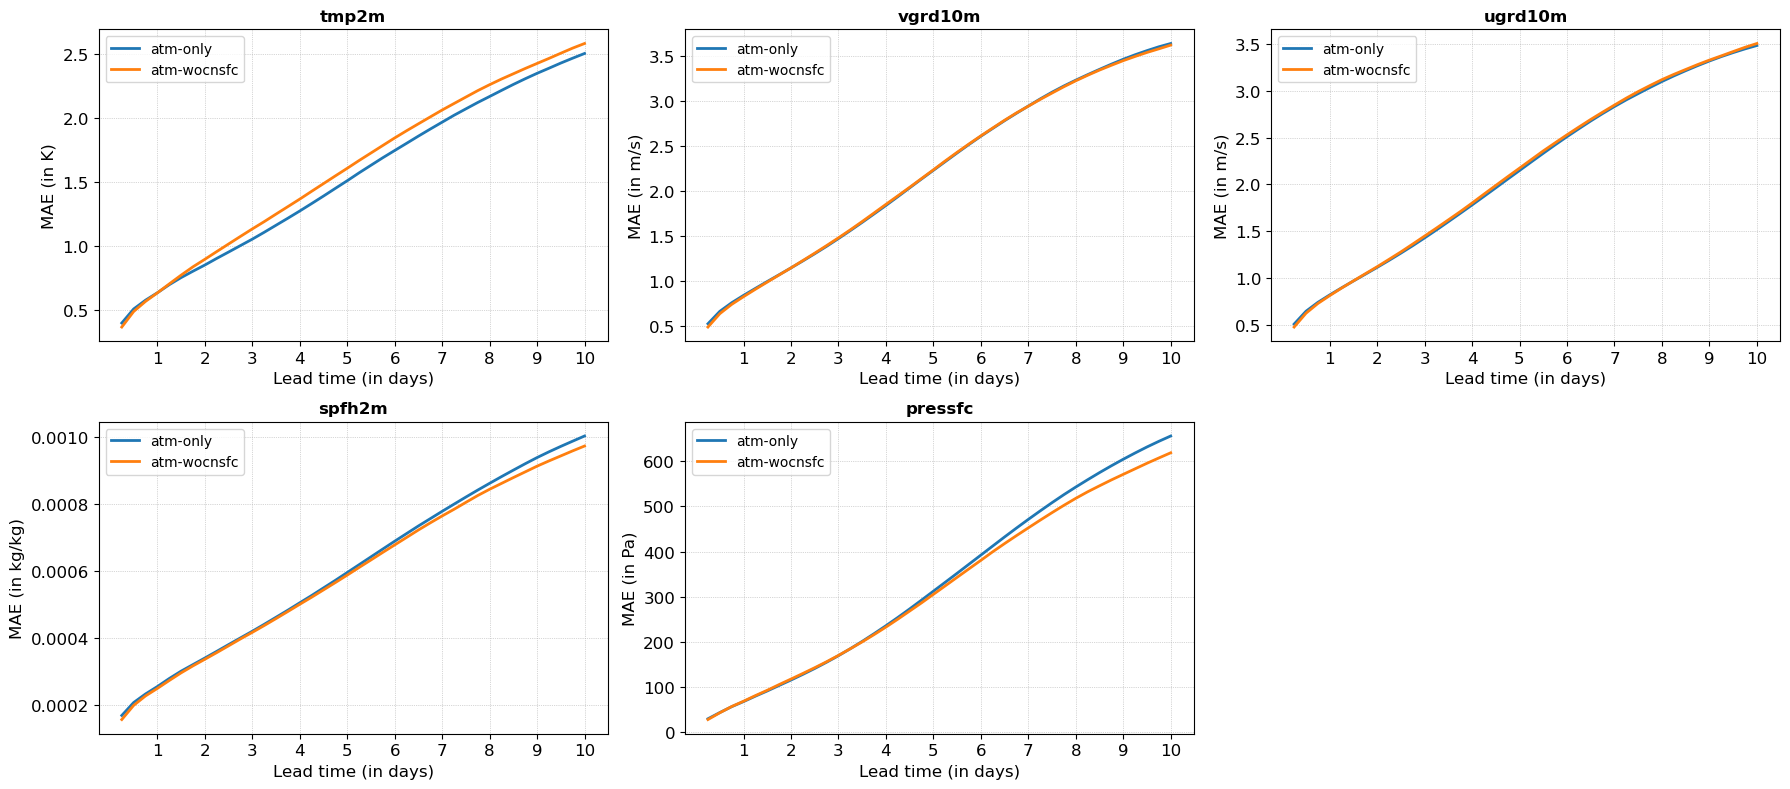

In [18]:
# plot -- 2D variables 
### NO LATITUDE WEIGHTING
nvars = len(common_vars_2d)
ncols = math.ceil(math.sqrt(nvars)) # make a square-ish box
nrows = math.ceil(nvars / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6,nrows*4))
axes = np.array(axes).flatten()

for i, v in enumerate(common_vars_2d):
    _ = plot_mae(axes[i], ds_pred1[v], ds_pred2[v], ds_tar1[v], ds_tar2[v], _prototype1, _prototype2,
                  var_name=v, units=ds_tar1[v].units)

for j in range(nvars, len(axes)): # turn off the unused axes
    axes[j].axis("off")

plt.tight_layout()
#plt.savefig("figures/MAEs_atm-only_vs_atm-wocnsfc_2d_atm_vars.png", dpi=300)
plt.show()

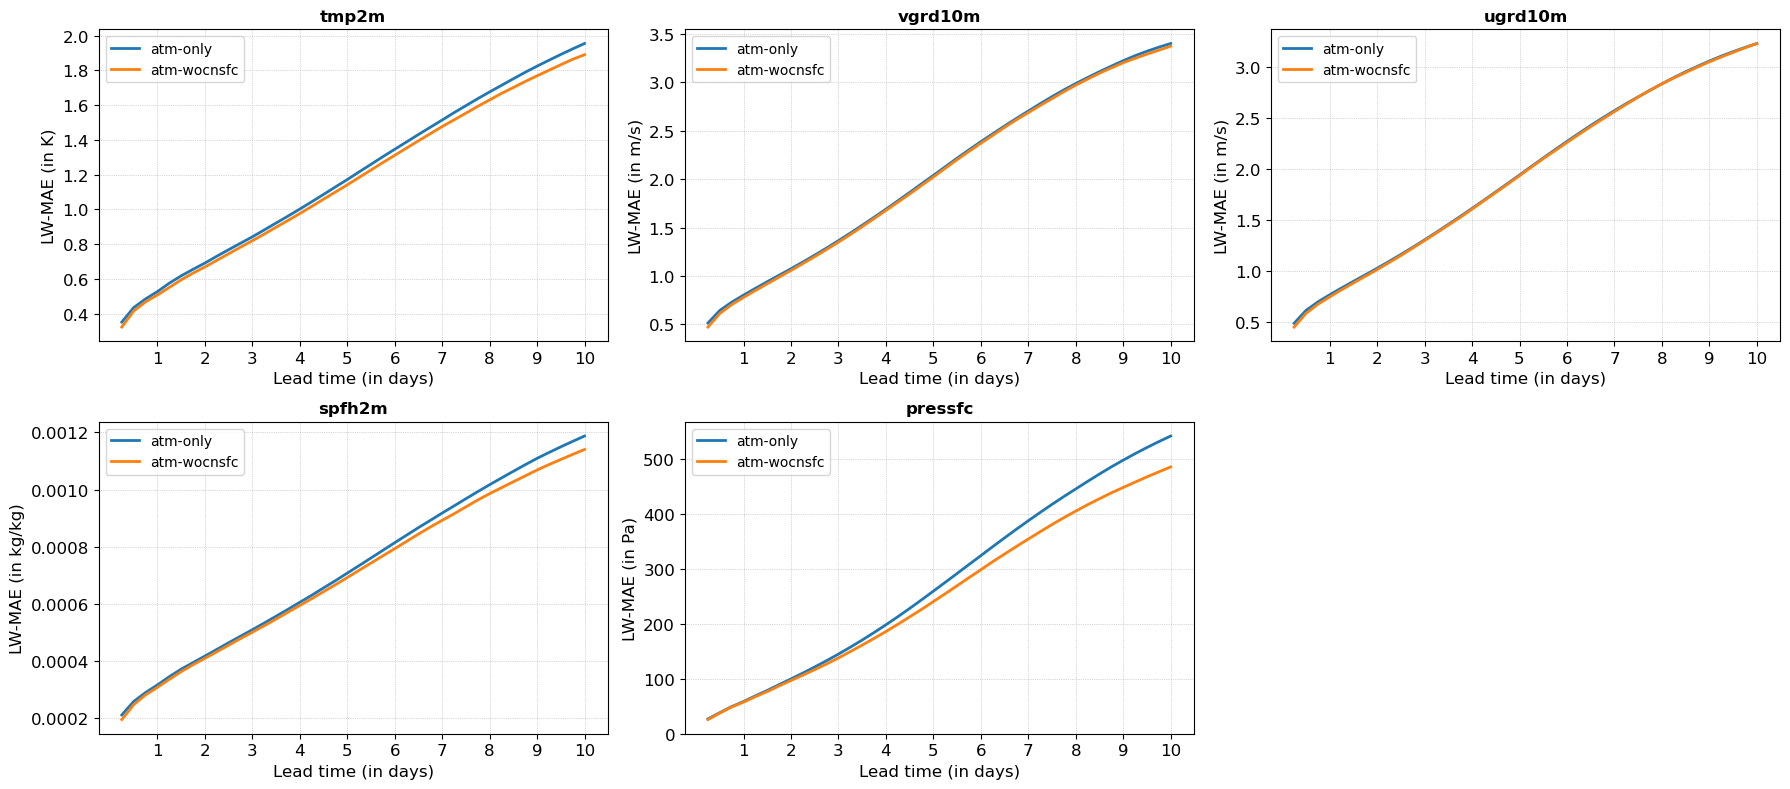

In [19]:
# plot -- 2D variables 
### LATITUDE WEIGHTING
nvars = len(common_vars_2d)
ncols = math.ceil(math.sqrt(nvars)) # make a square-ish box
nrows = math.ceil(nvars / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6,nrows*4))
axes = np.array(axes).flatten()

for i, v in enumerate(common_vars_2d):
    _ = plot_lw_mae(axes[i], ds_pred1[v], ds_pred2[v], ds_tar1[v], ds_tar2[v], _prototype1, _prototype2,
                    var_name=v, units=ds_tar1[v].units)

for j in range(nvars, len(axes)): # turn off the unused axes
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("figures/MAEs_atm-only_vs_atm-wocnsfc_2d_atm_vars_latitude_weighted.png", dpi=300)
plt.show()

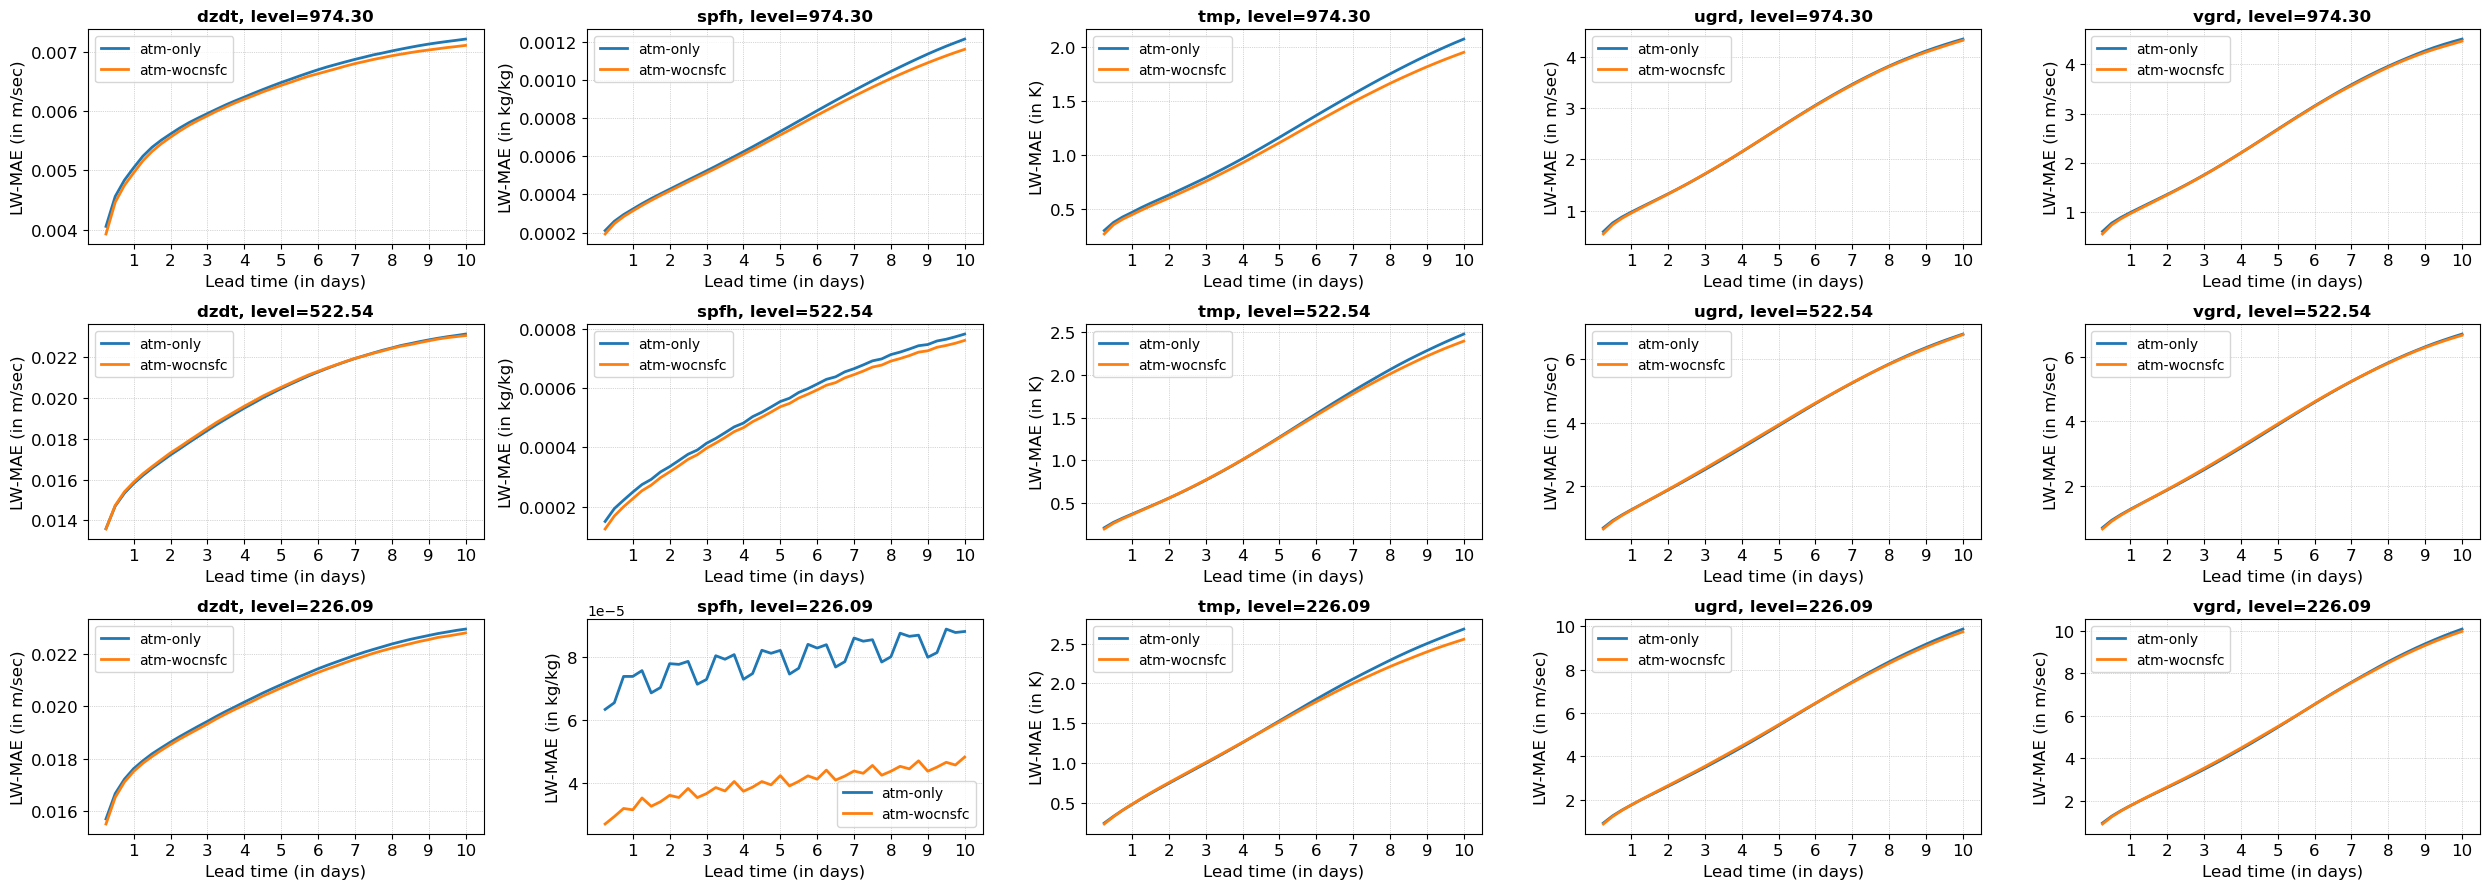

In [21]:
# plot - 3D variables
levels = [1000, 500, 200]
var = common_vars_3d
nvars = len(var)
ncols = nvars # make a square-ish box
nrows = len(levels)
#nrows = ds_pred1.sizes["level"]

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5,nrows*3))

for j, v in enumerate(var):
    for i, level in enumerate(levels): 
        _ = plot_lw_mae(axes[i][j], ds_pred1[v].sel(level=level, method="nearest"), ds_pred2[v].sel(level=level, method="nearest"), 
                      ds_tar1[v].sel(level=level, method="nearest"), ds_tar2[v].sel(level=level, method="nearest"), _prototype1, 
                      _prototype2, var_name=v, units=ds_tar1[v].units, level=ds_pred1.coords["level"].sel(level=level, method="nearest").values)

plt.savefig("figures/MAEs_atm-only_vs_atm-wocnsfc_3d_atm_vars_200-500-1000hPa_latitude_weighted.png", dpi=300)
plt.show()

## LW-RMSE and LW-MAE together

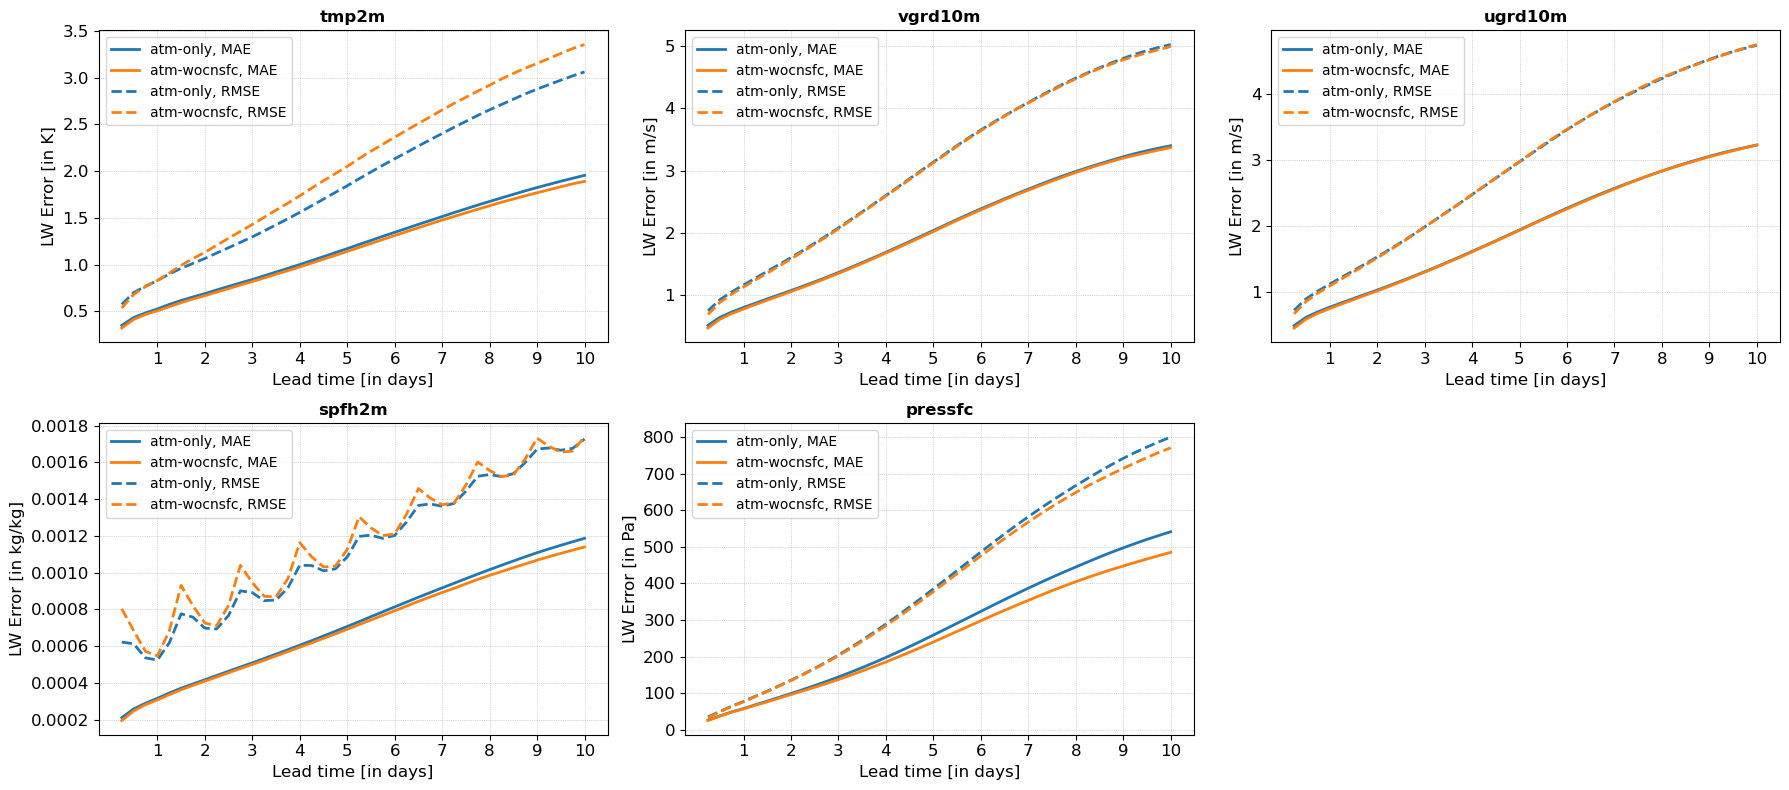

In [36]:
# plot -- 2D variables 
### LATITUDE WEIGHTING
nvars = len(common_vars_2d)
ncols = math.ceil(math.sqrt(nvars)) # make a square-ish box
nrows = math.ceil(nvars / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6,nrows*4))
axes = np.array(axes).flatten()

for i, v in enumerate(common_vars_2d):
    _ = plot_lw_mae(axes[i], ds_pred1[v], ds_pred2[v], ds_tar1[v], ds_tar2[v], 
                    _prototype1+", MAE", _prototype2+", MAE", var_name=v, 
                    units=ds_tar1[v].units, ylabel="LW Error")
    _ = plot_lw_rmse(axes[i], ds_pred1[v], ds_pred2[v], ds_tar1[v], ds_tar2[v], 
                     _prototype1+", RMSE", _prototype2+", RMSE", var_name=v, 
                     units=ds_tar1[v].units, ls=["--","--"], ylabel="LW Error")

for j in range(nvars, len(axes)): # turn off the unused axes
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("figures/LW-MAE_RMSE_atm-only_vs_atm-wocnsfc_2d_atm_vars_ics-2022.png", dpi=300)
plt.show()

# Co-variability